# Dependencies

In [1]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np

# Get to coding

## Initial setup
We start by defining our dimensions and batch sizes for inceptionV3, in order for it to work properly according to its documentation.

In [2]:
# Defining image dimensions and batch size
IMG_SIZE = (299, 299) # InceptionV3 expects inputs of at least 75x75, but 299x299 is standard for its pre-trained weights.
BATCH_SIZE = 32
VAL_SPLIT = 0.33
EPOCHS = 30

DATA_DIR_TRAIN = './grocery_dataset/train'
print("Training data is located at ", DATA_DIR_TRAIN)

DATA_DIR_VAL = './grocery_dataset/val'
print("Validation data is located at ", DATA_DIR_VAL)

DATA_DIR_TEST = './grocery_dataset/test'
print("Validation data is located at ", DATA_DIR_TEST)

Training data is located at  ./grocery_dataset/train
Validation data is located at  ./grocery_dataset/val
Validation data is located at  ./grocery_dataset/test


## Splitting the data

### Datasplit for training

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR_TRAIN,
    labels='inferred',
    label_mode='int',
    validation_split=VAL_SPLIT,
    subset='training',
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 15000 files belonging to 15 classes.
Using 10050 files for training.


2026-02-10 14:59:48.072486: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38811 MB memory:  -> device: 0, name: Quadro RTX 8000, pci bus id: 0000:83:00.0, compute capability: 7.5
2026-02-10 14:59:48.073123: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 11406 MB memory:  -> device: 1, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:02:00.0, compute capability: 6.1
2026-02-10 14:59:48.073675: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 11406 MB memory:  -> device: 2, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:03:00.0, compute capability: 6.1


### Datasplit for validation

In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR_VAL,
    labels='inferred',
    label_mode='int',
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3000 files belonging to 15 classes.
Using 990 files for validation.


### Class naming

In [5]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Total number of classes: {num_classes}")
print(f"Product categories: {class_names}")

Total number of classes: 15
Product categories: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


## Optimizing for performance
Adding caching is a good idea, since we dont want the GPU or CPU to wait for data loading.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Generating true labels

In [7]:
y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

## Setting up the model
### Loading the pretrained base of InceptionV3
Using InceptionV3'd ImageNet pre-trained dataset, but excluding the classification layer.

In [8]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models

# Instantiate the base model
base_model = InceptionV3(
    input_shape=IMG_SIZE + (3,), # Expected input shape
    include_top=False,           # Excluding the 1000-class classifier layer
    weights='imagenet'           # Use weights pre-trained on ImageNet
)

### Freezing the base model
We freeze the weights of the base of InceptionV3, preventing the random training on our dataset from destroying the base knowledge and patterns learned from ImageNet.

In [9]:
base_model.trainable = False # FREEZE the layers

### Adding our own little network
We add our own little network (a new head) on top of the frozen base. This head is responsible for taking the features extracted by InceptionV3  and classifying them into our product categories (num_classes).

In [10]:
global_average_layer = layers.GlobalAveragePooling2D() # Reducing the 3D feature map to a 1D vector
prediction_layer = layers.Dense(num_classes, activation='softmax') # Our final classification layer

data_augmentation = models.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),   # Flips images randomly
  layers.RandomRotation(0.2),                     # Rotates up to 20% (72 degrees)
  layers.RandomZoom(0.2),                         # Zooms in/out by 20%
])

# Combine the base and the head using the Functional API
model = models.Sequential([
    # Add the augmentation
    data_augmentation,

    # Add a preprocessing layer for InceptionV3's required input scaling (if not handled by the data loader)
    layers.Lambda(tf.keras.applications.inception_v3.preprocess_input, input_shape=(299, 299, 3)),
    base_model,
    global_average_layer,
    layers.Dropout(0.2), # Good practice to prevent overfitting
    prediction_layer
])

model.build(input_shape=(None, 299, 299, 3))

# Print the summary to see your new, smaller model head
model.summary()

model.save("model.keras")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 299, 299, 3)       0         
                                                                 
 lambda (Lambda)             (None, 299, 299, 3)       0         
                                                                 
 inception_v3 (Functional)   (None, 8, 8, 2048)        21802784  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 15)                30735     
                                                      

Compiling with adam optimizer to up the performance a little. Adam combines the best features of two optimizers i.e Momentum and RMSprop.


In [11]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss=keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])

## Time to train!
Training without fine tuning first...

In [12]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
)

Epoch 1/30


2026-02-10 15:00:02.256790: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8800
2026-02-10 15:00:06.332429: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fe235ed27b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-10 15:00:06.332490: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Quadro RTX 8000, Compute Capability 7.5
2026-02-10 15:00:06.332505: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2026-02-10 15:00:06.332523: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (2): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2026-02-10 15:00:06.347097: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1770732006.479819  950032 device_compile

315/315 [==============================] - 40s 90ms/step - loss: 1.6928 - accuracy: 0.5976 - val_loss: 0.8220 - val_accuracy: 0.9172
Epoch 2/30
315/315 [==============================] - 25s 80ms/step - loss: 0.6872 - accuracy: 0.8911 - val_loss: 0.4245 - val_accuracy: 0.9434
Epoch 3/30
315/315 [==============================] - 25s 79ms/step - loss: 0.4310 - accuracy: 0.9300 - val_loss: 0.2865 - val_accuracy: 0.9576
Epoch 4/30
315/315 [==============================] - 24s 75ms/step - loss: 0.3219 - accuracy: 0.9422 - val_loss: 0.2171 - val_accuracy: 0.9727
Epoch 5/30
315/315 [==============================] - 24s 77ms/step - loss: 0.2619 - accuracy: 0.9479 - val_loss: 0.1756 - val_accuracy: 0.9747
Epoch 6/30
315/315 [==============================] - 23s 72ms/step - loss: 0.2166 - accuracy: 0.9585 - val_loss: 0.1458 - val_accuracy: 0.9778
Epoch 7/30
315/315 [==============================] - 23s 72ms/step - loss: 0.1891 - accuracy: 0.9637 - val_loss: 0.1272 - val_accuracy: 0.9788
Epo

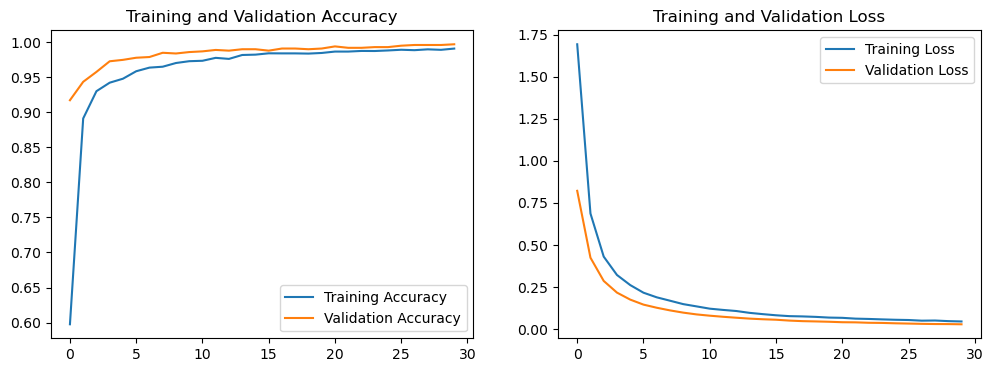

Training accuracy:  [0.5976119637489319, 0.8911442756652832, 0.9300497770309448, 0.9421890377998352, 0.9478607177734375, 0.9585074782371521, 0.9636815786361694, 0.964975118637085, 0.9702487587928772, 0.9728358387947083, 0.9734328389167786, 0.9776119589805603, 0.9761193990707397, 0.9816915392875671, 0.9821890592575073, 0.9840795993804932, 0.983980119228363, 0.983980119228363, 0.9836816191673279, 0.9845771193504333, 0.9865671396255493, 0.9865671396255493, 0.9874626994132996, 0.9873631596565247, 0.9881591796875, 0.9891542196273804, 0.9885572195053101, 0.9897512197494507, 0.9890547394752502, 0.990845799446106]
Validation accuracy:  [0.9171717166900635, 0.9434343576431274, 0.9575757384300232, 0.9727272987365723, 0.9747474789619446, 0.9777777791023254, 0.978787899017334, 0.9848484992980957, 0.9838383793830872, 0.9858585596084595, 0.986868679523468, 0.9888888597488403, 0.9878787994384766, 0.9898989796638489, 0.9898989796638489, 0.9878787994384766, 0.9909090995788574, 0.9909090995788574, 0.989

In [13]:
# Extract data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot the training and validation loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

print("Training accuracy: ", acc)
print("Validation accuracy: ", val_acc)

In [14]:
## Stress testing the model
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import preprocess_input

def TestAccuracy(path):
    img_path = path
    # Loading the image and resizing it to 299x299 (InceptionV3 standard)
    img = image.load_img(img_path, target_size=(299, 299))
    # Converting image to a numpy array and adding a "batch" dimension
    # (Keras expects a batch of images, even if it's just one)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    # Running the prediction
    predictions = model.predict(img_array)
    # Getting the class with the highest probability
    # score = tf.nn.softmax(predictions[0])
    score = predictions[0]
    predicted_class = class_names[np.argmax(score)]
    predicted_class_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100
    #for p in predictions:
    #    print(p / 100)
    
    print(f"I am {confidence:.2f}% sure this is a(n) {predicted_class} ({predicted_class_index}).")

TestAccuracy('./grocery_dataset/test/Carrot/1008.jpg') # Gulerod
TestAccuracy('./grocery_dataset/test/Pumpkin/1018.jpg') # Græskar
TestAccuracy('./grocery_dataset/test/Tomato/1015.jpg') # Tomat
TestAccuracy('./grocery_dataset/test/Brinjal/1056.jpg') # Brinjal
TestAccuracy('./grocery_dataset/test/Broccoli/1069.jpg') # Broccoli

1/1 [==============================] - 3s 3s/step
I am 99.62% sure this is a(n) Carrot (7).
1/1 [==============================] - 0s 34ms/step
I am 99.56% sure this is a(n) Pumpkin (12).
1/1 [==============================] - 0s 31ms/step
I am 44.55% sure this is a(n) Capsicum (6).
1/1 [==============================] - 0s 35ms/step
I am 98.01% sure this is a(n) Brinjal (3).
1/1 [==============================] - 0s 34ms/step
I am 98.79% sure this is a(n) Broccoli (4).


### Setting up confusion matrix and heatmap

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_grocery_confusion_matrix(y_true, y_pred, class_names):
    # 1. Compute the matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. Set up the figure size
    plt.figure(figsize=(10, 8))
    
    # 3. Create the heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, 
                yticklabels=class_names)
    
    plt.title('Grocery Recognition: Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

31/31 [==============================] - 2s 53ms/step


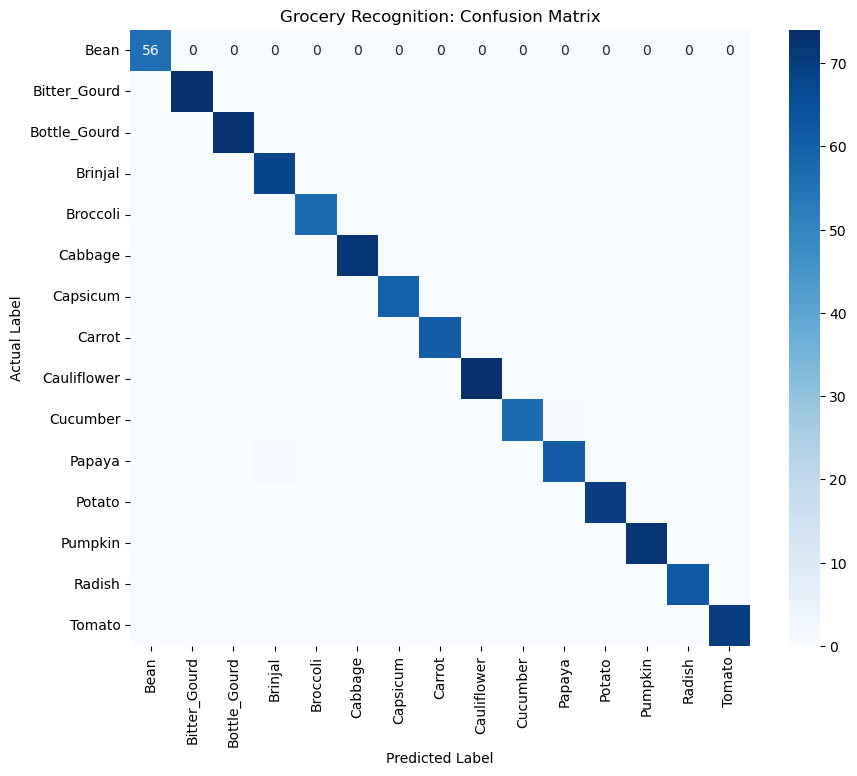

In [19]:
predictions = model.predict(val_ds)

y_pred = np.argmax(predictions, axis=1)

plot_grocery_confusion_matrix(y_true, y_pred, class_names)